In [67]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal as signal
from plotly import graph_objs as go
import tensorflow as tf

from src.known_attractors import van_der_pol_map, lorenz_map, run_map, plot_attractors
from src.fourier import plot_fourier, find_peaks

# Creating Fourier examples for the paper
### Quasi-periodicity 

In [ ]:
import numpy as np
import plotly.graph_objects as go

L = 800
n_dims = 3
samples_per_second = 30
dt = 1 / samples_per_second

def torus(t):
    R = 3
    r = 2
    omega = np.sqrt(2)   # irrational → quasi-periodic

    theta = 2 * np.pi * t
    phi = 2 * np.pi * omega * t

    x = (R + r * np.cos(phi)) * np.cos(theta)
    y = (R + r * np.cos(phi)) * np.sin(theta)
    z = r * np.sin(phi)

    return np.array([x, y, z])

raw_attractor = np.zeros((L, n_dims))
for i in range(L):
    raw_attractor[i, :] = torus(i *dt)

torus_attractor = raw_attractor
plot_attractors(raw_attractor)

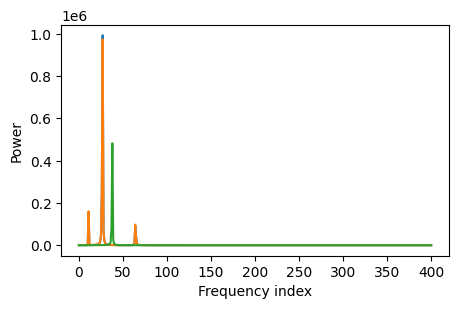

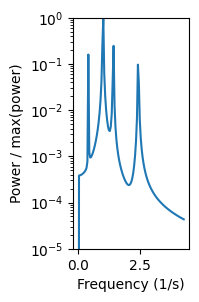

[0.4125 1.0125 1.425  2.4   ]


In [68]:
power, freqs = plot_fourier(raw_attractor, dt, filename="quasi")
print(freqs[find_peaks(power)])

In [66]:
f1, f2, f3, f4 = 0.4125, 1.0125, 1.425,  2.4

1*f1 + 2*f2

2.4375

### Periodic: Van der Pol

In [47]:
dt = 0.05
states_np = run_map(tf.constant([1.0, 1.0, 2.0]), van_der_pol_map, steps=5000, step_size=dt)
plot_attractors(states_np)

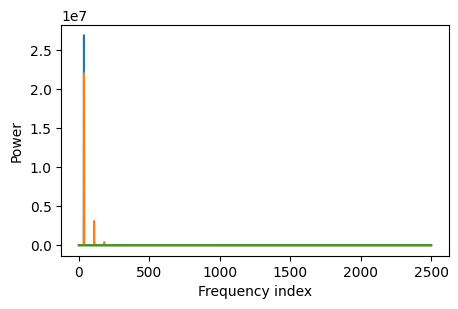

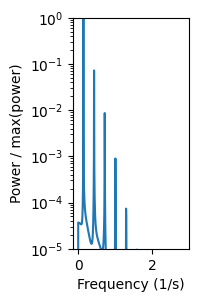

[4.000e-03 1.440e-01 4.320e-01 7.200e-01 8.560e-01 1.008e+00 1.188e+00
 1.296e+00 1.588e+00 1.872e+00 1.920e+00 2.160e+00 2.200e+00 2.452e+00
 2.740e+00 3.028e+00 3.320e+00 3.608e+00 9.992e+00]


In [49]:
power, freqs = plot_fourier(states_np, dt, filename="periodic")

print(freqs[find_peaks(power)])

### Chaos: Lorenz

In [42]:
dt = 0.01
states_np = run_map(tf.constant([1.0, 0.0, 0.0]), lorenz_map, steps=5000, step_size=dt)
plot_attractors(states_np)

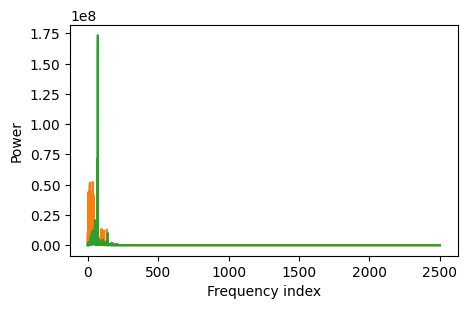

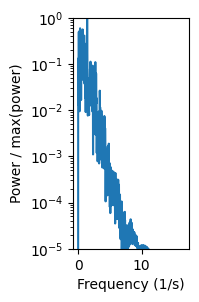

[4.000e-02 1.200e-01 1.600e-01 2.200e-01 2.600e-01 3.200e-01 4.000e-01
 4.600e-01 5.000e-01 5.400e-01 5.800e-01 6.400e-01 7.200e-01 7.600e-01
 8.200e-01 8.600e-01 9.000e-01 9.800e-01 1.040e+00 1.120e+00 1.160e+00
 1.220e+00 1.300e+00 1.380e+00 1.440e+00 1.560e+00 1.600e+00 1.680e+00
 1.760e+00 1.800e+00 1.880e+00 1.920e+00 1.960e+00 2.000e+00 2.040e+00
 2.120e+00 2.160e+00 2.220e+00 2.260e+00 2.300e+00 2.340e+00 2.400e+00
 2.440e+00 2.500e+00 2.540e+00 2.600e+00 2.640e+00 2.680e+00 2.720e+00
 2.780e+00 2.840e+00 2.900e+00 2.980e+00 3.160e+00 3.220e+00 3.280e+00
 3.340e+00 3.380e+00 3.420e+00 3.480e+00 3.540e+00 3.600e+00 3.640e+00
 3.680e+00 3.720e+00 3.760e+00 3.800e+00 3.880e+00 3.960e+00 4.020e+00
 4.060e+00 4.140e+00 4.220e+00 4.260e+00 4.400e+00 4.480e+00 4.520e+00
 4.560e+00 4.600e+00 4.640e+00 4.680e+00 4.720e+00 4.760e+00 4.800e+00
 4.840e+00 4.900e+00 4.940e+00 4.980e+00 5.020e+00 5.060e+00 5.100e+00
 5.180e+00 5.220e+00 5.260e+00 5.300e+00 5.340e+00 5.380e+00 5.440e+00
 5.520

<Figure size 640x480 with 0 Axes>

In [ ]:
power, freqs = plot_fourier(states_np, dt)

print(freqs[find_peaks(power)])